# Notebook Pengujian
## Tugas Besar 1 IF3270 Pembelajaran Mesin

**Anggota**
- 13523070 - Sebastian Hung Yansen
- 13523082 - Aramazaya

## 0. Import Libraries and Load Data

In [4]:
# 0. Import Libraries and Load Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score
from importlib import reload
import ffnn

# Load Dataset
train_df = pd.read_csv("dataset/datasetml_2026.csv")
print("Dataset shape:", train_df.shape)
train_df.head()

Dataset shape: (10000, 12)


,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


## 1. Exploratory Data Analysis (EDA)

### 1.1. Gambaran Umum Dataset

In [5]:
train_df.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cgpa                      10000 non-null  float64
 1   backlogs                  10000 non-null  int64  
 2   college_tier              10000 non-null  object 
 3   country                   10000 non-null  object 
 4   university_ranking_band   10000 non-null  object 
 5   internship_count          10000 non-null  int64  
 6   aptitude_score            10000 non-null  float64
 7   communication_score       10000 non-null  float64
 8   specialization            10000 non-null  object 
 9   industry                  10000 non-null  object 
 10  internship_quality_score  10000 non-null  float64
 11  placement_status          10000 non-null  object 
dtypes: float64(4), int64(2), object(6)
memory usage: 937.6+ KB


### 1.2. Statistik Deskriptif

In [7]:
train_df.describe(include='all')

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
count,10000.000000,10000.000000,10000,10000,10000,10000.00000,10000.000000,10000.000000,10000,10000,10000.000000,10000
unique,NaN,NaN,3,5,3,NaN,NaN,NaN,5,6,NaN,2
top,NaN,NaN,Tier 2,Germany,300+,NaN,NaN,NaN,Data Science,Consulting,NaN,Placed
freq,NaN,NaN,3993,2057,4075,NaN,NaN,NaN,2036,1739,NaN,6153
mean,6.998290,1.248100,NaN,NaN,NaN,1.49930,69.877531,65.158600,NaN,NaN,5.021436,NaN
std,0.802606,1.149904,NaN,NaN,NaN,1.20289,14.700532,14.740446,NaN,NaN,1.505975,NaN
min,4.000000,0.000000,NaN,NaN,NaN,0.00000,30.000000,30.000000,NaN,NaN,1.000000,NaN
25%,6.461928,0.000000,NaN,NaN,NaN,1.00000,59.880399,55.112244,NaN,NaN,4.012656,NaN
50%,6.997924,1.000000,NaN,NaN,NaN,1.00000,70.097368,65.006484,NaN,NaN,5.017335,NaN
75%,7.536865,2.000000,NaN,NaN,NaN,2.00000,80.213934,75.277248,NaN,NaN,6.031400,NaN


### 1.3. Distribusi Kelas Target

In [8]:
print(train_df['placement_status'].value_counts())
print(train_df['placement_status'].value_counts(normalize=True).round(3))

placement_status
Placed        6153
Not Placed    3847
Name: count, dtype: int64
placement_status
Placed        0.615
Not Placed    0.385
Name: proportion, dtype: float64


### 1.4. Distribusi Fitur Numerik

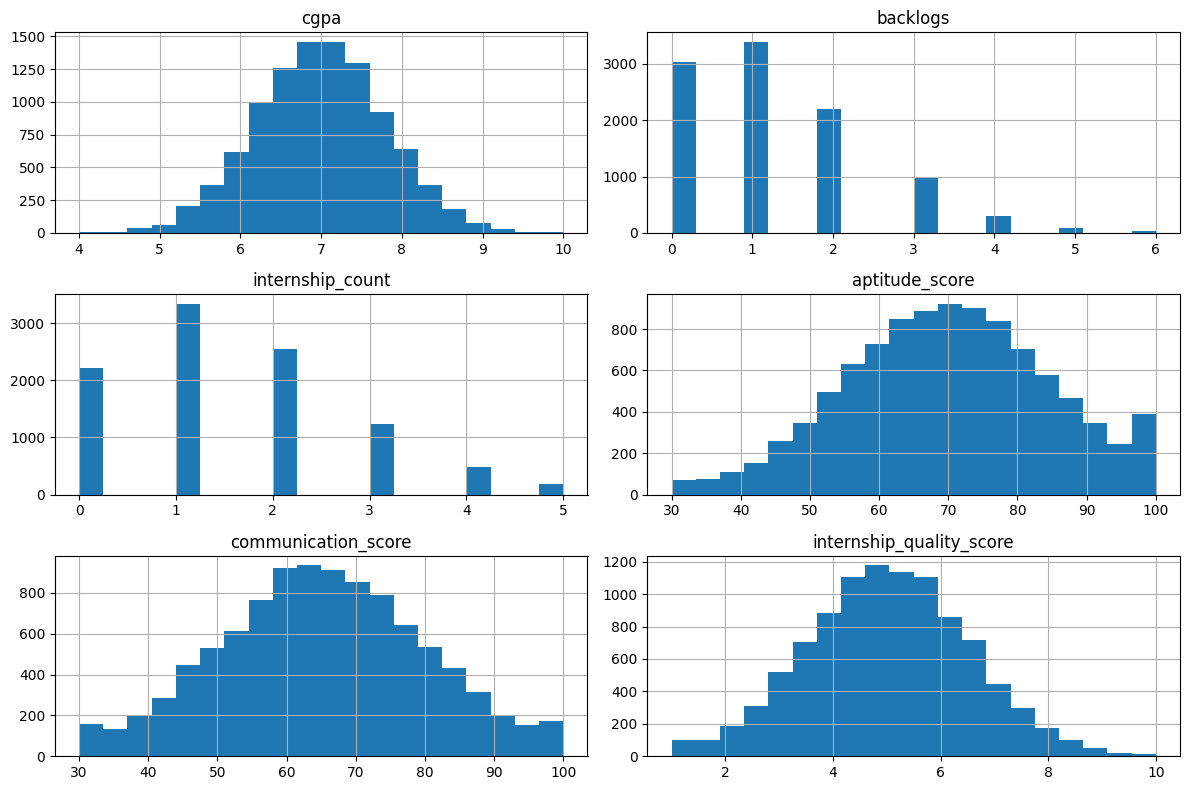

In [10]:
numeric_cols = ["cgpa", "backlogs", "internship_count",
                "aptitude_score", "communication_score",
                "internship_quality_score"]

train_df[numeric_cols].hist(bins=20, figsize=(12, 8)) # histogram
plt.tight_layout()
plt.show()

### 1.5. Distribusi Fitur Kategorikal

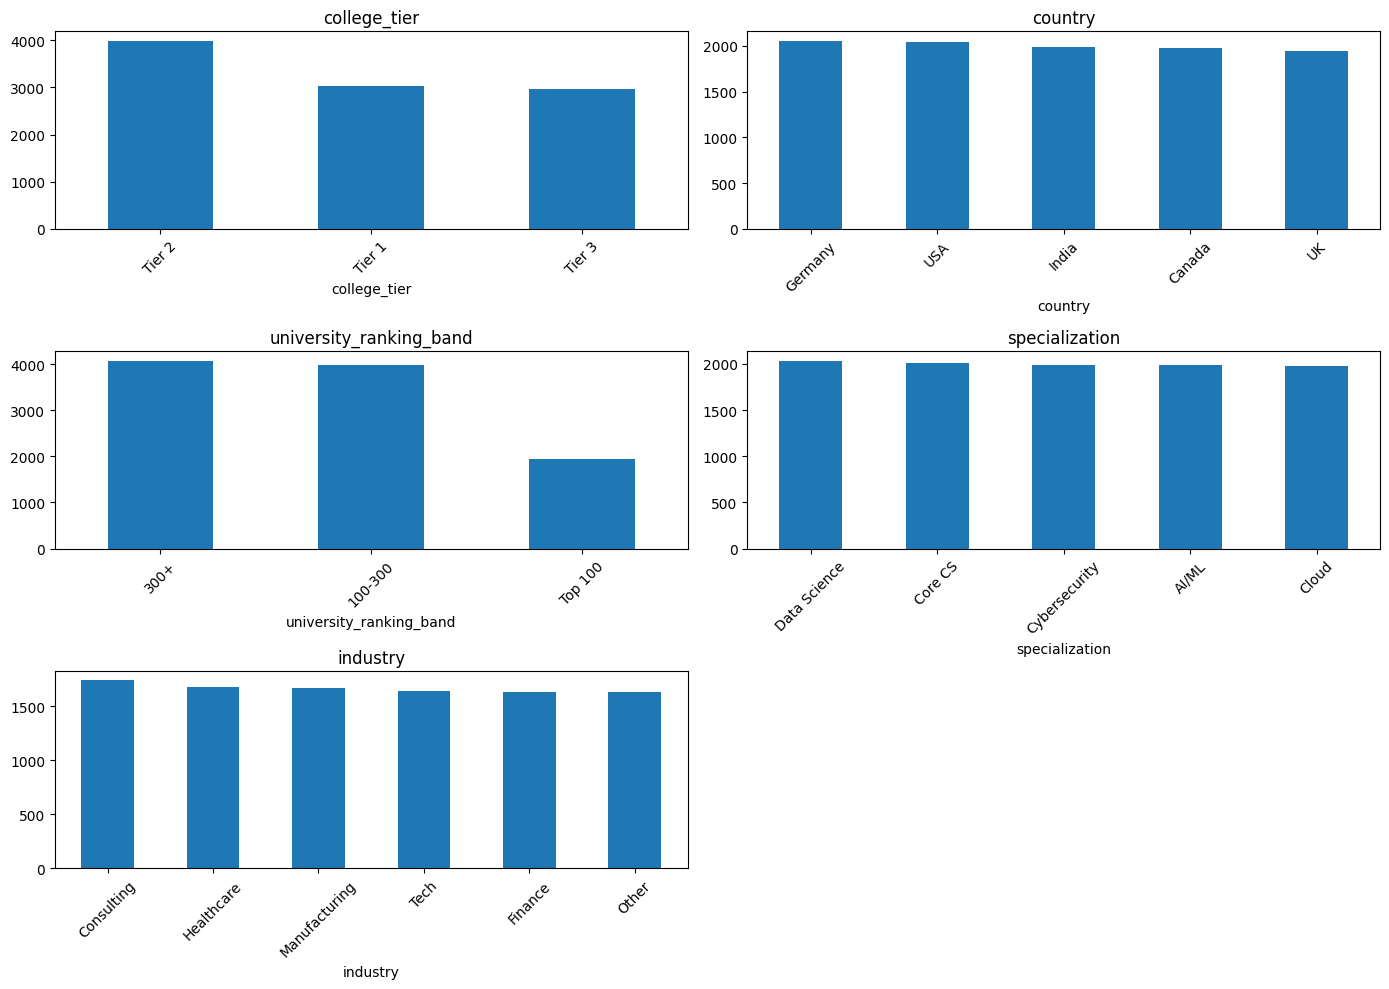

In [11]:
cat_cols = ["college_tier", "country",
            "university_ranking_band",
            "specialization", "industry"]

plt.figure(figsize=(14, 10))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(3, 2, i) # barplot
    train_df[col].value_counts().plot(kind="bar")
    plt.title(col)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. Data Preprocessing

In [12]:
df = train_df.copy()

# Target: mapping ke 0/1
y_raw = df["placement_status"].map({"Placed": 1, "Not Placed": 0}).values

# Fitur
X_raw = df.drop(columns=["placement_status"])

cat_cols = X_raw.select_dtypes(include=["object"]).columns
num_cols = X_raw.select_dtypes(exclude=["object"]).columns

print("Categorical columns:", list(cat_cols))
print("Numeric columns:", list(num_cols))

Categorical columns: ['college_tier', 'country', 'university_ranking_band', 'specialization', 'industry']
Numeric columns: ['cgpa', 'backlogs', 'internship_count', 'aptitude_score', 'communication_score', 'internship_quality_score']


### One-Hot Encoding untuk fitur kategorikal

In [13]:
enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

X_cat = enc.fit_transform(X_raw[cat_cols])
X_num = X_raw[num_cols].values

X = np.concatenate([X_num, X_cat], axis=1)
y = y_raw

print("Final feature shape:", X.shape)

Final feature shape: (10000, 28)


In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_raw[num_cols].values)
X = np.concatenate([X_num_scaled, X_cat], axis=1)

## Train/Validation Split

In [15]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape, "X_val:", X_val.shape)
print("y_train positive ratio:", y_train.mean().round(3))
print("y_val positive ratio:", y_val.mean().round(3))

X_train: (8000, 28) X_val: (2000, 28)
y_train positive ratio: 0.615
y_val positive ratio: 0.616


## 3. Wrapper / Helper untuk FFNN

In [16]:
from importlib import reload
import ffnn
reload(ffnn)
from ffnn import FeedForwardNN

def train_ffnn_config(
    layer_sizes=[X_train.shape[1], 4, 4, 2],
    activations=['linear', 'relu', 'sigmoid'],
    loss_function="binary_cross_entropy",
    learning_rate=0.01,
    epochs=20,
    batch_size=1,
    weight_init="normal",
    weight_variance=0.01,
    verbose=True,
):
    model = FeedForwardNN(
        neurons=layer_sizes,
        activation_function=activations,
        loss_function=loss_function,
        learning_rate=learning_rate,
        loss_threshold=0.01,
        epochs=epochs,
        weight_init=weight_init,
        weight_variance=weight_variance,
        batch_size=batch_size,
        verbose=verbose,
    )

    history = model.fit(X_train, y_train, X_val=X_val, y_val=y_val)

    # Predictions on validation set
    y_val_pred_raw = model.predict(X_val)

    # If model outputs probabilities (continuous), convert to class labels
    # Handle both shape (n_samples,) and (n_samples, 1)
    import numpy as np
    if isinstance(y_val_pred_raw, np.ndarray) and y_val_pred_raw.dtype != int:
        if y_val_pred_raw.ndim == 1:
            y_val_pred = (y_val_pred_raw >= 0.5).astype(int)
        elif y_val_pred_raw.ndim == 2 and y_val_pred_raw.shape[1] == 1:
            y_val_pred = (y_val_pred_raw[:, 0] >= 0.5).astype(int)
        else:
            y_val_pred = np.argmax(y_val_pred_raw, axis=1)
    else:
        y_val_pred = y_val_pred_raw

    from sklearn.metrics import accuracy_score
    acc = accuracy_score(y_val, y_val_pred)

    return model, y_val_pred_raw, y_val_pred, acc, history

## 4. Eksperimen Hyperparameter

In [14]:
configs_depth_width = [
    # Width variation (depth tetap: 2 hidden layer)
    {"name": "width_small",  "layer_sizes": [X_train.shape[1], 2, 2, 2]},
    {"name": "width_medium", "layer_sizes": [X_train.shape[1], 4, 4, 2]},
    {"name": "width_large",  "layer_sizes": [X_train.shape[1], 8, 8, 2]},
    # Depth variation (width tetap: 32 neuron)
    {"name": "depth_1", "layer_sizes": [X_train.shape[1], 4, 2]},
    {"name": "depth_2", "layer_sizes": [X_train.shape[1], 4, 4, 2]},
    {"name": "depth_3", "layer_sizes": [X_train.shape[1], 4, 4, 4, 2]},
]

results_depth_width = []

for cfg in configs_depth_width:
    print(f"Training config: {cfg['name']}, layers={cfg['layer_sizes']}")
    model, y_val_pred_raw, y_val_pred, acc, _ = train_ffnn_config(
        layer_sizes=cfg["layer_sizes"],
        epochs=20
    )
    results_depth_width.append(
        {"name": cfg["name"], "layer_sizes": cfg["layer_sizes"],
         "model": model, "y_val_pred_raw": y_val_pred_raw,
         "y_val_pred": y_val_pred, "acc": acc, "history": _}
    )
    print(f"  Validation accuracy: {acc:.4f}")

Training config: width_small, layers=[28, 2, 2, 2]
Epoch 1/5, Loss: 1.335531, Val Loss: 1.334739
Epoch 2/5, Loss: 1.333788, Val Loss: 1.334739
Epoch 3/5, Loss: 1.333788, Val Loss: 1.334739
Epoch 4/5, Loss: 1.333788, Val Loss: 1.334739
Epoch 5/5, Loss: 1.333788, Val Loss: 1.334739
  Validation accuracy: 0.6155
Training config: width_medium, layers=[28, 4, 4, 2]
Epoch 1/5, Loss: 1.335460, Val Loss: 1.334653
Epoch 2/5, Loss: 1.172570, Val Loss: 1.037664
Epoch 3/5, Loss: 0.988746, Val Loss: 1.020276
Epoch 4/5, Loss: 0.984629, Val Loss: 1.020705
Epoch 5/5, Loss: 0.983007, Val Loss: 1.020283
  Validation accuracy: 0.7595
Training config: width_large, layers=[28, 8, 8, 2]
Epoch 1/5, Loss: 1.335472, Val Loss: 1.334695
Epoch 2/5, Loss: 1.220020, Val Loss: 1.040405
Epoch 3/5, Loss: 0.990186, Val Loss: 1.028001
Epoch 4/5, Loss: 0.985057, Val Loss: 1.020510
Epoch 5/5, Loss: 0.983293, Val Loss: 1.020904
  Validation accuracy: 0.7575
Training config: depth_1, layers=[28, 4, 2]
Epoch 1/5, Loss: 1.035

In [ ]:
plt.figure(figsize=(8, 5))
for res in results_depth_width:
    hist = res["history"]
    epochs_range = range(1, len(hist["train_loss"]) + 1)
    plt.plot(epochs_range, hist["train_loss"], label=f"{res['name']} - train")
    if hist["val_loss"]:
        plt.plot(epochs_range, hist["val_loss"], linestyle="--", label=f"{res['name']} - val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (semua variasi)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

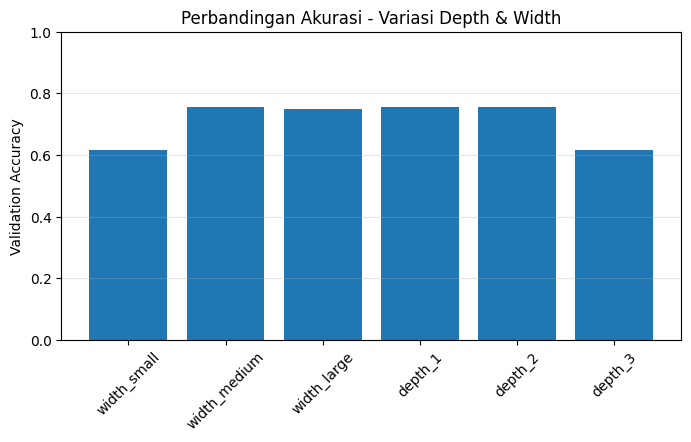

In [ ]:
# Plot akurasi untuk setiap konfigurasi depth/width

names = [r["name"] for r in results_depth_width]
accs = [r["acc"] for r in results_depth_width]

plt.figure(figsize=(8, 4))
plt.bar(names, accs)
plt.xticks(rotation=45)
plt.ylabel("Validation Accuracy")
plt.title("Perbandingan Akurasi - Variasi Depth & Width")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.show()

## 5. Eksperimen Fungsi Aktivasi Hidden Layer

In [ ]:
test_layer_index = 1

activation_candidates = ["relu", "sigmoid", "tanh", "linear", "log", "abs", "exp", "leaky_relu", "elu"]
results_activation = []

for act in activation_candidates:
    hidden_acts = ["relu", "relu"]
    hidden_acts[test_layer_index - 1] = act
    activations = hidden_acts + ["sigmoid"]

    print(f"Training dengan activation {activations} pada hidden layer ke-{test_layer_index}")
    model, y_val_pred_raw, y_val_pred, acc, _ = train_ffnn_config(
        activations=activations,
    )
    results_activation.append(
        {"activation": act, "model": model,
         "y_val_pred_raw": y_val_pred_raw,
         "y_val_pred": y_val_pred, "acc": acc, "history": _}
    )
    print(f"  Validation accuracy: {acc:.4f}")

Training dengan activation ['relu', 'relu', 'sigmoid'] pada hidden layer ke-1
Epoch 1/20, Loss: 1.335479, Val Loss: 1.334739
Epoch 2/20, Loss: 1.333771, Val Loss: 1.334686
Epoch 3/20, Loss: 1.235037, Val Loss: 1.036692
Epoch 4/20, Loss: 0.997494, Val Loss: 1.024067
Epoch 5/20, Loss: 0.989340, Val Loss: 1.022241
Epoch 6/20, Loss: 0.987025, Val Loss: 1.021393
Epoch 7/20, Loss: 0.986071, Val Loss: 1.019042
Epoch 8/20, Loss: 0.984760, Val Loss: 1.021698
Epoch 9/20, Loss: 0.984349, Val Loss: 1.021876
Epoch 10/20, Loss: 0.983154, Val Loss: 1.021015
Epoch 11/20, Loss: 0.982781, Val Loss: 1.019911
Epoch 12/20, Loss: 0.981799, Val Loss: 1.021133
Epoch 13/20, Loss: 0.981477, Val Loss: 1.022361
Epoch 14/20, Loss: 0.980422, Val Loss: 1.025731
Epoch 15/20, Loss: 0.979765, Val Loss: 1.021806
Epoch 16/20, Loss: 0.979639, Val Loss: 1.022849
Epoch 17/20, Loss: 0.979126, Val Loss: 1.021991
Epoch 18/20, Loss: 0.978775, Val Loss: 1.021021
Epoch 19/20, Loss: 0.978550, Val Loss: 1.023532
Epoch 20/20, Loss: 

In [1]:
plt.figure(figsize=(8, 5))
for res in results_activation:
    hist = res["history"]
    epochs_range = range(1, len(hist["train_loss"]) + 1)
    plt.plot(epochs_range, hist["train_loss"], label=f"Training Loss")
    if hist["val_loss"]:
        plt.plot(epochs_range, hist["val_loss"], linestyle="--", label=f"Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (semua variasi)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

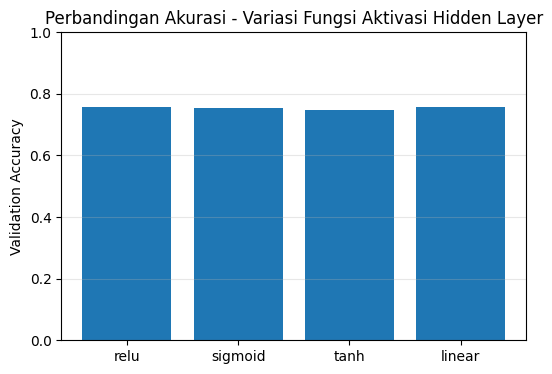

In [ ]:
# Plot akurasi untuk variasi fungsi aktivasi

names = [r["activation"] for r in results_activation]
accs = [r["acc"] for r in results_activation]

plt.figure(figsize=(6, 4))
plt.bar(names, accs)
plt.ylabel("Validation Accuracy")
plt.title("Perbandingan Akurasi - Variasi Fungsi Aktivasi Hidden Layer")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.show()

## 6. Eksperimen Learning Rate

In [19]:
learning_rates = [0.001, 0.01, 0.1]
results_lr = []

for lr in learning_rates:
    print(f"Training dengan learning rate = {lr}")
    model, y_val_pred_raw, y_val_pred, acc, _ = train_ffnn_config(
        learning_rate = lr
    )
    results_lr.append(
        {"lr": lr, "model": model,
         "y_val_pred_raw": y_val_pred_raw,
         "y_val_pred": y_val_pred, "acc": acc, "history": _}
    )
    print(f"  Validation accuracy: {acc:.4f}")

Training dengan learning rate = 0.001
Epoch 1/20, Loss: 1.346392, Val Loss: 1.333382
Epoch 2/20, Loss: 1.333121, Val Loss: 1.332448
Epoch 3/20, Loss: 1.332849, Val Loss: 1.332446
Epoch 4/20, Loss: 1.332842, Val Loss: 1.332446
Epoch 5/20, Loss: 1.332839, Val Loss: 1.332443
Epoch 6/20, Loss: 1.332834, Val Loss: 1.332438
Epoch 7/20, Loss: 1.332827, Val Loss: 1.332429
Epoch 8/20, Loss: 1.332814, Val Loss: 1.332414
Epoch 9/20, Loss: 1.332792, Val Loss: 1.332385
Epoch 10/20, Loss: 1.332748, Val Loss: 1.332323
Epoch 11/20, Loss: 1.332646, Val Loss: 1.332169
Epoch 12/20, Loss: 1.332354, Val Loss: 1.331678
Epoch 13/20, Loss: 1.331235, Val Loss: 1.329460
Epoch 14/20, Loss: 1.323475, Val Loss: 1.308870
Epoch 15/20, Loss: 1.207946, Val Loss: 1.051739
Epoch 16/20, Loss: 0.999547, Val Loss: 1.009324
Epoch 17/20, Loss: 0.982752, Val Loss: 1.007988
Epoch 18/20, Loss: 0.979593, Val Loss: 1.008373
Epoch 19/20, Loss: 0.977903, Val Loss: 1.008502
Epoch 20/20, Loss: 0.976877, Val Loss: 1.007782
  Validatio

In [20]:
plt.figure(figsize=(8, 5))
for res in results_lr:
    hist = res["history"]
    epochs_range = range(1, len(hist["train_loss"]) + 1)
    plt.plot(epochs_range, hist["train_loss"], label=f"Training Loss")
    if hist["val_loss"]:
        plt.plot(epochs_range, hist["val_loss"], linestyle="--", label=f"Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (semua variasi)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

KeyError: 'name'

<Figure size 800x500 with 0 Axes>

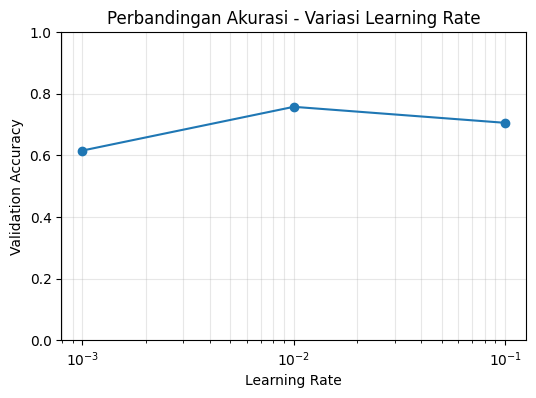

In [ ]:
# Plot akurasi untuk variasi learning rate

lrs = [r["lr"] for r in results_lr]
accs = [r["acc"] for r in results_lr]

plt.figure(figsize=(6, 4))
plt.plot(lrs, accs, marker="o")
plt.xscale("log")
plt.xlabel("Learning Rate")
plt.ylabel("Validation Accuracy")
plt.title("Perbandingan Akurasi - Variasi Learning Rate")
plt.ylim(0, 1)
plt.grid(True, which="both", axis="both", alpha=0.3)
plt.show()

## 7. Eksperimen Inisialisasi Bobot

In [ ]:
weights = ["zeros", "random", "normal"]
results_w = []

for w in weights:
    model, y_val_pred_raw, y_val_pred, acc, _ = train_ffnn_config(
        weight_init=w,
    )
    results_w.append(
        {"w": w, "model": model,
         "y_val_pred_raw": y_val_pred_raw,
         "y_val_pred": y_val_pred, "acc": acc, "history": _}
    )
    print(f"  Validation accuracy: {acc:.4f}")

In [ ]:
plt.figure(figsize=(8, 5))
for res in results_w:
    hist = res["history"]
    epochs_range = range(1, len(hist["train_loss"]) + 1)
    plt.plot(epochs_range, hist["train_loss"], label=f"Training Loss")
    if hist["val_loss"]:
        plt.plot(epochs_range, hist["val_loss"], linestyle="--", label=f"Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (semua variasi)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
ws = [w["w"] for w in results_w]
accs = [w["acc"] for w in results_w]

plt.figure(figsize=(6, 4))
plt.plot(lrs, accs, marker="o")
plt.xscale("log")
plt.xlabel("Weight")
plt.ylabel("Validation Accuracy")
plt.title("Perbandingan Akurasi - Variasi Inisialisasi Bobot")
plt.ylim(0, 1)
plt.grid(True, which="both", axis="both", alpha=0.3)
plt.show()

## 8. Regularisasi L1 vs L2 vs None

In [ ]:
def train_ffnn_with_l1_l2(
    layer_sizes,
    activations,
    reg_type=None,          # None | "l1" | "l2"
    reg_lambda=0.0,
    learning_rate=0.01,
    epochs=5,
    batch_size=1,
):
    model = FeedForwardNN(
        neurons=layer_sizes,
        activation_function=activations,
        loss_function="binary_cross_entropy",
        learning_rate=learning_rate,
        epochs=epochs,
        batch_size=batch_size,
        weight_init="random",
        weight_lb=-0.1,
        weight_ub=0.1,
        verbose=False,
    )

    model.fit(X_train, y_train)

    y_val_pred_raw = model.predict(X_val)
    y_val_pred = (y_val_pred_raw >= 0.5).astype(int)
    base_loss = 1 - accuracy_score(y_val, y_val_pred)  # proxy "loss" from accuracy

    all_weights = []
    for layer in [model.input_layer] + model.hidden_layers + [model.output_layer]:
        for row in layer.weights:
            for w in row:
                all_weights.append(w.data)
    W = np.array(all_weights)

    if reg_type == "l1":
        penalty = reg_lambda * np.sum(np.abs(W))
    elif reg_type == "l2":
        penalty = reg_lambda * np.sum(W ** 2)
    else:
        penalty = 0.0

    total_loss_proxy = base_loss + penalty

    return model, y_val_pred_raw, y_val_pred, base_loss, penalty, total_loss_proxy, history

In [ ]:
regularizers = [
    {"name": "none", "type": None,  "lambda": 0.0},
    {"name": "l1",   "type": "l1",  "lambda": 1e-4},
    {"name": "l2",   "type": "l2",  "lambda": 1e-4},
]

results_reg = []

for reg in regularizers:
    print(f"Training dengan regularizer = {reg['name']}")
    model, y_val_pred_raw, y_val_pred, base_loss, penalty, total_loss, history = train_ffnn_with_l1_l2(
        layer_sizes=[X_train.shape[1], 4, 4, 2],
        activations=["relu", "relu", "sigmoid"],
        reg_type=reg["type"],
        reg_lambda=reg["lambda"]
    )
    acc = accuracy_score(y_val, y_val_pred)
    results_reg.append(
        {"name": reg["name"], "model": model,
         "acc": acc, "base_loss": base_loss,
         "penalty": penalty, "total_loss": total_loss, "history": history}
    )
    print(f"  Validation accuracy: {acc:.4f}, base_loss≈{base_loss:.4f}, penalty≈{penalty:.4f}")

Training dengan regularizer = none
  Validation accuracy: 0.7565, base_loss≈0.2435, penalty≈0.0000
Training dengan regularizer = l1
  Validation accuracy: 0.7565, base_loss≈0.2435, penalty≈0.0035
Training dengan regularizer = l2
  Validation accuracy: 0.7565, base_loss≈0.2435, penalty≈0.0020


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
for res in results_reg:
    hist = res["history"]
    epochs_range = range(1, len(hist["train_loss"]) + 1)
    plt.plot(epochs_range, hist["train_loss"], label=f"{res['name']} - train", marker="o", markersize=2, linestyle="-")
    if hist["val_loss"]:
        plt.plot(epochs_range, hist["val_loss"], label=f"{res['name']} - val", marker="s", markersize=2, linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss per Epoch (Regularisasi: None vs L1 vs L2)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

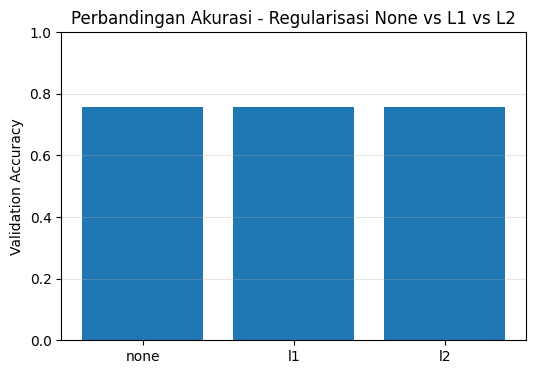

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

names = [r["name"] for r in results_reg]
accs = [r["acc"] for r in results_reg]
base_losses = [r["base_loss"] for r in results_reg]
penalties = [r["penalty"] for r in results_reg]
total_losses = [r["total_loss"] for r in results_reg]

x = np.arange(len(names))
width = 0.25

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Kiri: Accuracy
ax1.bar(x - width/2, accs, width, label="Accuracy", color=["#2ecc71", "#3498db", "#9b59b6"])
ax1.set_ylabel("Accuracy")
ax1.set_title("Validation Accuracy per Regularizer")
ax1.set_xticks(x)
ax1.set_xticklabels(names)
ax1.set_ylim(0, 1.05)
ax1.legend()

# Kanan: Base loss, penalty, total loss (grouped bars)
ax2.bar(x - width, base_losses, width, label="Base loss (1 - acc)")
ax2.bar(x, penalties, width, label="Penalty (L1/L2)")
ax2.bar(x + width, total_losses, width, label="Total loss")
ax2.set_ylabel("Loss")
ax2.set_title("Loss components per Regularizer")
ax2.set_xticks(x)
ax2.set_xticklabels(names)
ax2.legend()

plt.tight_layout()
plt.show()

## 9. Perbandingan dengan library sklearn MLP

In [ ]:
from sklearn.neural_network import MLPClassifier

best_ffnn_cfg = [X_train.shape[1], 4, 4, 2]
best_ffnn_acts = ["linear", "relu", "sigmoid"]

ffnn_model, y_val_pred_raw, y_val_pred, ffnn_acc, _ = train_ffnn_config(
    layer_sizes=best_ffnn_cfg,
    activations=best_ffnn_acts,
)

# Train sklearn MLP dengan hyperparameter yang mirip
mlp = MLPClassifier(
    hidden_layer_sizes=(32, 32),
    activation="relu",
    learning_rate_init=0.01,
    max_iter=200,
    random_state=42,
)
mlp.fit(X_train, y_train)
y_val_pred_sklearn = mlp.predict(X_val)
mlp_acc = accuracy_score(y_val, y_val_pred_sklearn)

print(f"Akurasi FFNN (from scratch): {ffnn_acc:.4f}")
print(f"Akurasi sklearn MLP:         {mlp_acc:.4f}")

Epoch 1/20, Loss: 1.335479
Epoch 2/20, Loss: 1.333771
Epoch 3/20, Loss: 1.235037
Epoch 4/20, Loss: 0.997494
Epoch 5/20, Loss: 0.989340
Epoch 6/20, Loss: 0.987025
Epoch 7/20, Loss: 0.986071
Epoch 8/20, Loss: 0.984760
Epoch 9/20, Loss: 0.984349
Epoch 10/20, Loss: 0.983154
Epoch 11/20, Loss: 0.982781
Epoch 12/20, Loss: 0.981799
Epoch 13/20, Loss: 0.981477
Epoch 14/20, Loss: 0.980422
Epoch 15/20, Loss: 0.979765
Epoch 16/20, Loss: 0.979639
Epoch 17/20, Loss: 0.979126
Epoch 18/20, Loss: 0.978775
Epoch 19/20, Loss: 0.978550
Epoch 20/20, Loss: 0.978858
Akurasi FFNN (from scratch): 0.7575
Akurasi sklearn MLP:         0.6865


## 10. Gradient Descent vs Adam

Training dengan Gradient Descent (SGD)...
Epoch 1/20, Loss: 0.485009, Val Loss: 0.476832
Epoch 2/20, Loss: 0.475629, Val Loss: 0.476832
Epoch 3/20, Loss: 0.475629, Val Loss: 0.476832
Epoch 4/20, Loss: 0.475629, Val Loss: 0.476832
Epoch 5/20, Loss: 0.475629, Val Loss: 0.476832
Epoch 6/20, Loss: 0.475629, Val Loss: 0.476832
Epoch 7/20, Loss: 0.475629, Val Loss: 0.476832
Epoch 8/20, Loss: 0.475629, Val Loss: 0.476832
Epoch 9/20, Loss: 0.475629, Val Loss: 0.476832
Epoch 10/20, Loss: 0.475629, Val Loss: 0.476832
Epoch 11/20, Loss: 0.475629, Val Loss: 0.476832
Epoch 12/20, Loss: 0.475629, Val Loss: 0.476832
Epoch 13/20, Loss: 0.475629, Val Loss: 0.476832
Epoch 14/20, Loss: 0.475629, Val Loss: 0.476832
Epoch 15/20, Loss: 0.475629, Val Loss: 0.476832
Epoch 16/20, Loss: 0.475629, Val Loss: 0.476832
Epoch 17/20, Loss: 0.475629, Val Loss: 0.476832
Epoch 18/20, Loss: 0.475629, Val Loss: 0.476832
Epoch 19/20, Loss: 0.475629, Val Loss: 0.476832
Epoch 20/20, Loss: 0.475629, Val Loss: 0.476832
Trainin

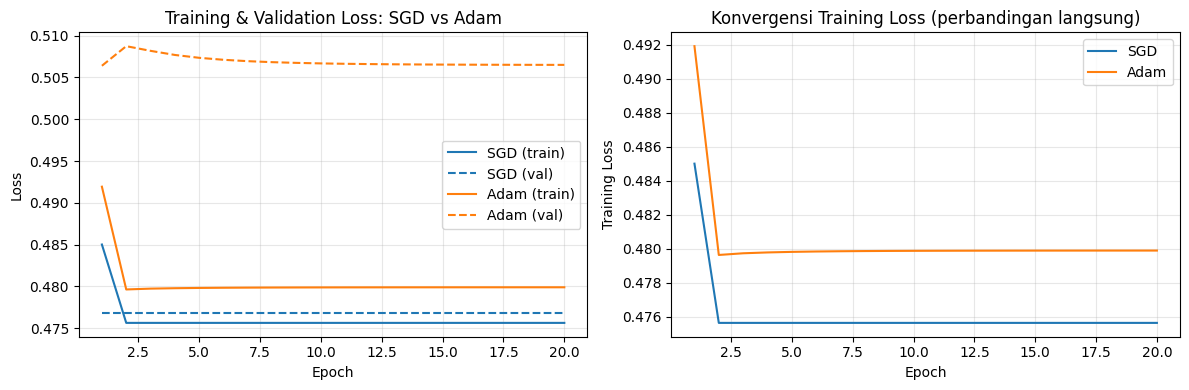


--- Ringkasan Perbandingan SGD vs Adam ---
SGD  — Waktu: 753.43s | Epochs: 20 | Final train loss: 0.475629 | Val loss: 0.476832 | Val accuracy: 0.3845
Adam — Waktu: 772.01s | Epochs: 20 | Final train loss: 0.479889 | Val loss: 0.506509 | Val accuracy: 0.3845


In [37]:
from importlib import reload
import ffnn
reload(ffnn)
from ffnn import FeedForwardNN
import time

# --- Training dengan Gradient Descent (SGD) ---
print("Training dengan Gradient Descent (SGD)...")
t0_sgd = time.perf_counter()
model_sgd = FeedForwardNN(
    neurons=[X_train.shape[1], 4, 4, 2],
    epochs=20,
    optimizer="sgd",
)
history_sgd = model_sgd.fit(X_train, y_train, X_val=X_val, y_val=y_val)
time_sgd = time.perf_counter() - t0_sgd

# --- Training dengan Adam ---
print("Training dengan Adam...")
t0_adam = time.perf_counter()
model_adam = FeedForwardNN(
    neurons=[X_train.shape[1], 4, 4, 2],
    epochs=20,
    optimizer="adam",
)
history_adam = model_adam.fit(X_train, y_train, X_val=X_val, y_val=y_val)
time_adam = time.perf_counter() - t0_adam

# --- Prediksi & akurasi ---
y_val_pred_sgd = model_sgd.predict(X_val)
y_val_pred_adam = model_adam.predict(X_val)
# predict() untuk 2 kelas mengembalikan argmax (0/1); pastikan shape cocok dengan y_val
if y_val_pred_sgd.ndim > 1:
    y_val_pred_sgd = np.argmax(y_val_pred_sgd, axis=1)
if y_val_pred_adam.ndim > 1:
    y_val_pred_adam = np.argmax(y_val_pred_adam, axis=1)
acc_sgd = accuracy_score(y_val, y_val_pred_sgd)
acc_adam = accuracy_score(y_val, y_val_pred_adam)

# --- Plot perbandingan konvergensi ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_sgd = range(1, len(history_sgd["train_loss"]) + 1)
epochs_adam = range(1, len(history_adam["train_loss"]) + 1)

axes[0].plot(epochs_sgd, history_sgd["train_loss"], label="SGD (train)", color="C0", linestyle="-")
axes[0].plot(epochs_sgd, history_sgd["val_loss"], label="SGD (val)", color="C0", linestyle="--")
axes[0].plot(epochs_adam, history_adam["train_loss"], label="Adam (train)", color="C1", linestyle="-")
axes[0].plot(epochs_adam, history_adam["val_loss"], label="Adam (val)", color="C1", linestyle="--")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training & Validation Loss: SGD vs Adam")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_sgd, history_sgd["train_loss"], label="SGD", color="C0")
axes[1].plot(epochs_adam, history_adam["train_loss"], label="Adam", color="C1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Training Loss")
axes[1].set_title("Konvergensi Training Loss (perbandingan langsung)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Ringkasan analisis ---
print("\n--- Ringkasan Perbandingan SGD vs Adam ---")
print(f"SGD  — Waktu: {time_sgd:.2f}s | Epochs: {len(history_sgd['train_loss'])} | Final train loss: {history_sgd['train_loss'][-1]:.6f} | Val loss: {history_sgd['val_loss'][-1]:.6f} | Val accuracy: {acc_sgd:.4f}")
print(f"Adam — Waktu: {time_adam:.2f}s | Epochs: {len(history_adam['train_loss'])} | Final train loss: {history_adam['train_loss'][-1]:.6f} | Val loss: {history_adam['val_loss'][-1]:.6f} | Val accuracy: {acc_adam:.4f}")

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=b044e4c2-05db-4863-aa0c-338d172fe23a' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>